# **Home Credit Risk Project**

## **Abstract**

The Home Credit challenge is a very well-known event in the Data Science community. It occurred in 2018 on the Kaggle platform, and the goal was to encourage data scientists to create the best predicting model for a very attractive reward. Although the challenge is a bit “old”, this project tries to gather all the data from the Home Credit database to create a predictive model that not only can predict the defaults, but also explains why the default phenomenon happens. It aims to give real business insights on how to deal with clients, backed by economical and statistical background. This project approach mixes classical econometric techniques and analysis with fancy Machine Learning modeling and support, to offer the best of two worlds: Prediction and Explanation. And of course, a very tedious feature engineering process with key variable selections and filtering from the database and predictive relevance, as will be shown in the next sections.


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import statsmodels.api as sm
import plotly.io as pio
pio.renderers.default = "png"
import warnings
warnings.filterwarnings('ignore')

In [27]:
connection=sqlite3.connect("home_credit.db")

## **Feature Engineering**


This section contains the Database Treatment, Data Cleaning, and Feature Selection sub-sections. The Database Treatment shows the usage of SQL to select almost all variables from the following Home Credit tables:

application_train

bureau

installments_payments

previous_applications
(all .csv files)

The rest of the tables were discarded for this project as the trade-off between selection, depuration, and statistical gain seemed not really worth it (referring specifically to the balances tables).
The Data Cleaning sub-section basically mixes a bit of SQL with Pandas usage for handling the NaNs, which weren’t that many.
Finally, in the longest sub-section, Feature Selection (only 1 cell), the Machine Learning model XGBoost was used for selecting the most relevant variables of the dataset, ordered according to their predictive power for the XGBoost model.

### **Database Treatment**

As stated before, this section contains a (very) tedious process of handling the database, employing several queries and temporal queries for the selection and for applying functions to the clients' historical tables. For this process, a Python loop was generated for uploading each table to the database, then I printed the proportion of defaulted clients in a dataframe. This proportion was around 8.07% of clients who did not pay their loans, a very standard number in credit firms.


In [ ]:
tables=[
    "application_test",
   "application_train",
    "bureau",
    "bureau_balance",
    "credit_card_balance",
    "installments_payments",
    "POS_CASH_balance",
    "previous_application",
    "sample_submission"
]
for t in tables:
    route=f"home_credit/{t}.csv"
    df_t=pd.read_csv(route)
    df_t.to_sql(t,connection,if_exists="replace",index=False,chunksize=10000)

In [28]:
query_target="""
SELECT TARGET, COUNT(*) as clients
FROM application_train
GROUP BY TARGET;
"""
df_clients=pd.read_sql(query_target,connection)
df_clients["proportion"]=(df_clients["clients"]/df_clients["clients"].sum())*100
df_clients["proportion"]=df_clients["proportion"].round(2).astype(str)+"%"
df_clients

,TARGET,clients,proportion
0,0,282686,91.93%
1,1,24825,8.07%


Then I started selecting and organizing the variables (or columns) of the database from the bureau table. Since this table contains multiple records of a single client (each one of them identified with the SK_ID_CURR variable), I collapsed the multiple records using strategic functions into a single variable each; therefore, the merge with application_train became possible. The criteria for this function selection was pretty straightforward. Using a bit of business insight of the credit market industry, the historical amounts were organized with sums or maximums depending on the type of variable, while the days were summarized as averages or maximums, again depending on the type of variable.

Both in this sub-section and the Data Cleaning sub-section, the software DB Browser (SQLite) was used as a tool to know the values of each variable and have a real sense on how to filter, handle the NaNs, and summarize the information. This software was used instead of the SQLite Viewer extension since the dataset was too large for the free version of the extension (maybe when I get a job I’ll be able to afford the PRO version).

In [ ]:
query_clients="""
WITH BureauSummaryAMT AS (
    SELECT SK_ID_CURR, MAX(AMT_CREDIT_MAX_OVERDUE) AS max_overdue_amount,
    SUM(AMT_CREDIT_SUM) AS total_debt_amount,
    SUM(AMT_CREDIT_SUM_DEBT) AS current_debt,
    SUM(AMT_CREDIT_SUM_LIMIT) AS current_credit_limit,
    SUM(AMT_CREDIT_SUM_OVERDUE) AS current_overdue_amount
    FROM bureau
    GROUP BY SK_ID_CURR
),
BureauDays AS (
    SELECT  SK_ID_CURR, 
    AVG(DAYS_CREDIT) AS avg_days_application_cb,
    MAX(CREDIT_DAY_OVERDUE) AS max_day_overdue,
    AVG(DAYS_CREDIT_ENDDATE) AS avg_days_credit,
    MAX(DAYS_ENDDATE_FACT) AS max_days_no_debt
    FROM bureau
    GROUP BY SK_ID_CURR
)
SELECT 
A.*,
B_amt.*,
B_days.*
FROM application_train as A
LEFT JOIN BureauSummaryAMT AS B_amt ON A.SK_ID_CURR=B_amt.SK_ID_CURR
LEFT JOIN BureauDays AS B_days ON A.SK_ID_CURR=B_days.SK_ID_CURR;
"""
df_clients_historial=pd.read_sql(query_clients,connection)
df_clients_historial = df_clients_historial.loc[:, ~df_clients_historial.columns.duplicated()]
df_clients_historial

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_YEAR,max_overdue_amount,total_debt_amount,current_debt,current_credit_limit,current_overdue_amount,avg_days_application_cb,max_day_overdue,avg_days_credit,max_days_no_debt
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,1.0,5043.645,865055.565,245781.00,31988.565,0.0,-874.000000,0.0,-349.000000,-36.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.000,1017400.500,0.00,810000.000,0.0,-1400.750000,0.0,-544.500000,-540.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.000,189037.800,0.00,0.000,0.0,-867.000000,0.0,-488.500000,-382.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.000,146250.000,0.00,0.000,0.0,-1149.000000,0.0,-783.000000,-783.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,1.0,NaN,3960000.000,1795833.00,0.000,0.0,-867.500000,0.0,280.500000,-794.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,NaN,45000.000,0.00,NaN,0.0,-1104.000000,0.0,-859.000000,-859.0


In [ ]:
df_pure_bureau=pd.read_csv("home_credit/bureau.csv")
df_bureau_cat=df_pure_bureau.select_dtypes(include=["object","str"])
df_bureau_cat["SK_ID_CURR"]=df_pure_bureau["SK_ID_CURR"]
df_bureau_cat

,CREDIT_ACTIVE,CREDIT_CURRENCY,CREDIT_TYPE,SK_ID_CURR
0,Closed,currency 1,Consumer credit,215354
1,Active,currency 1,Credit card,215354
2,Active,currency 1,Consumer credit,215354
3,Active,currency 1,Credit card,215354
4,Active,currency 1,Consumer credit,215354
...,...,...,...,...
1716423,Active,currency 1,Microloan,259355
1716424,Closed,currency 1,Consumer credit,100044
1716425,Closed,currency 1,Consumer credit,100044
1716426,Closed,currency 1,Consumer credit,246829


In [ ]:
df_bureau_dummies=pd.get_dummies(df_bureau_cat,columns=[
    "CREDIT_ACTIVE",
    "CREDIT_CURRENCY",
    "CREDIT_TYPE",
],dtype=int)
df_bureau_dummies

,SK_ID_CURR,CREDIT_ACTIVE_Active,CREDIT_ACTIVE_Bad debt,CREDIT_ACTIVE_Closed,CREDIT_ACTIVE_Sold,CREDIT_CURRENCY_currency 1,CREDIT_CURRENCY_currency 2,CREDIT_CURRENCY_currency 3,CREDIT_CURRENCY_currency 4,CREDIT_TYPE_Another type of loan,...,CREDIT_TYPE_Interbank credit,CREDIT_TYPE_Loan for business development,CREDIT_TYPE_Loan for purchase of shares (margin lending),CREDIT_TYPE_Loan for the purchase of equipment,CREDIT_TYPE_Loan for working capital replenishment,CREDIT_TYPE_Microloan,CREDIT_TYPE_Mobile operator loan,CREDIT_TYPE_Mortgage,CREDIT_TYPE_Real estate loan,CREDIT_TYPE_Unknown type of loan
0,215354,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,215354,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,215354,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,215354,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,215354,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1716424,100044,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1716425,100044,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1716426,246829,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df_clients_historial=df_clients_historial.merge((df_bureau_dummies.groupby("SK_ID_CURR").sum()),how="left",on="SK_ID_CURR")
df_clients_historial.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,CREDIT_TYPE_Interbank credit,CREDIT_TYPE_Loan for business development,CREDIT_TYPE_Loan for purchase of shares (margin lending),CREDIT_TYPE_Loan for the purchase of equipment,CREDIT_TYPE_Loan for working capital replenishment,CREDIT_TYPE_Microloan,CREDIT_TYPE_Mobile operator loan,CREDIT_TYPE_Mortgage,CREDIT_TYPE_Real estate loan,CREDIT_TYPE_Unknown type of loan
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,263491.000000,263491.000000,263491.000000,263491.000000,263491.000000,263491.000000,263491.000000,263491.000000,263491.000000,263491.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.000004,0.006532,0.000015,0.000065,0.001431,0.034176,0.000004,0.059232,0.000087,0.001791
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.001948,0.101560,0.003896,0.008491,0.044529,0.484475,0.001948,0.260005,0.009342,0.046964
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,10.000000,1.000000,2.000000,5.000000,79.000000,1.000000,13.000000,1.000000,4.000000


In [ ]:
query_prev="""
SELECT SK_ID_CURR, COUNT(SK_ID_PREV) AS previous_loans,
MAX(AMT_ANNUITY) AS max_prev_annuity,
MAX(AMT_APPLICATION) AS max_prev_ammount,
MAX(AMT_CREDIT) AS max_prev_final_ammount,
MAX(AMT_DOWN_PAYMENT) AS max_prev_down_ammount,
MAX(AMT_GOODS_PRICE) AS max_prev_goods_price,
SUM(CASE WHEN NAME_CONTRACT_STATUS="Approved" THEN 1 ELSE 0 END) AS prev_approved_credits,
SUM(CASE WHEN NAME_CONTRACT_STATUS="Refused" THEN 1 ELSE 0 END) AS prev_refused_credits,
SUM(CASE WHEN NAME_CONTRACT_STATUS="Canceled" THEN 1 ELSE 0 END) AS prev_canceled_credits,
SUM(CASE WHEN NAME_CONTRACT_STATUS="Unused offer" THEN 1 ELSE 0 END) AS unusual_credits,
MAX(DAYS_DECISION) AS min_days_decision,
MAX(DAYS_FIRST_DRAWING) AS max_days_drawing,
MAX(DAYS_FIRST_DUE) AS min_days_first_due,
MAX(DAYS_LAST_DUE_1ST_VERSION) AS min_days_last_due_original,
MAX(DAYS_LAST_DUE) AS min_days_last_due_real,
MAX(DAYS_TERMINATION) AS min_days_credit_termination,
AVG(RATE_DOWN_PAYMENT) AS avg_down_payment,
AVG(RATE_INTEREST_PRIMARY) AS avg_interest_charged,
AVG(CNT_PAYMENT) AS avg_cnt,
SUM(NFLAG_INSURED_ON_APPROVAL) AS credits_insured_prev
FROM previous_application
GROUP BY SK_ID_CURR
"""
df_previous_application=pd.read_sql(query_prev,connection)
df_previous_application=df_previous_application.loc[:,~df_previous_application.columns.duplicated()]
df_previous_str=pd.read_csv("home_credit/previous_application.csv")
dummy_columns=[
    "CODE_REJECT_REASON",
    "NAME_CLIENT_TYPE",
    "NAME_PORTFOLIO",
    "NAME_CASH_LOAN_PURPOSE",
    "NAME_GOODS_CATEGORY",
    "PRODUCT_COMBINATION",
    "NAME_PAYMENT_TYPE",
    "NAME_PRODUCT_TYPE"]
df_previous_cat=df_previous_str[["SK_ID_CURR"]+dummy_columns]
df_previous_cat=pd.get_dummies(df_previous_cat,dtype=int)
df_previous_application=df_previous_application.merge((df_previous_cat.groupby("SK_ID_CURR").sum()),how="left",on="SK_ID_CURR")
df_clients_historial=df_clients_historial.merge(df_previous_application,how="left",on="SK_ID_CURR")
df_clients_historial

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PRODUCT_COMBINATION_POS mobile without interest,PRODUCT_COMBINATION_POS other with interest,PRODUCT_COMBINATION_POS others without interest,NAME_PAYMENT_TYPE_Cash through the bank,NAME_PAYMENT_TYPE_Cashless from the account of the employer,NAME_PAYMENT_TYPE_Non-cash from your account,NAME_PAYMENT_TYPE_XNA,NAME_PRODUCT_TYPE_XNA,NAME_PRODUCT_TYPE_walk-in,NAME_PRODUCT_TYPE_x-sell
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,2.0,0.0,0.0,1.0,2.0,0.0,1.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,4.0,0.0,0.0,5.0,5.0,0.0,4.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,5.0,0.0,0.0,1.0,2.0,1.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0


In [ ]:
df_clients_historial.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,PRODUCT_COMBINATION_POS mobile without interest,PRODUCT_COMBINATION_POS other with interest,PRODUCT_COMBINATION_POS others without interest,NAME_PAYMENT_TYPE_Cash through the bank,NAME_PAYMENT_TYPE_Cashless from the account of the employer,NAME_PAYMENT_TYPE_Non-cash from your account,NAME_PAYMENT_TYPE_XNA,NAME_PRODUCT_TYPE_XNA,NAME_PRODUCT_TYPE_walk-in,NAME_PRODUCT_TYPE_x-sell
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,291057.000000,291057.000000,291057.000000,291057.000000,291057.000000,291057.000000,291057.000000,291057.00000,291057.000000,291057.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.068337,0.069777,0.007198,3.032739,0.003233,0.024394,1.796761,3.09236,0.440649,1.324119
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.290373,0.316696,0.094368,2.676267,0.071596,0.200520,2.373333,2.60067,1.097137,1.990060
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,1.000000,2.00000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,4.000000,0.000000,0.000000,3.000000,4.00000,0.000000,2.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,15.000000,13.000000,5.000000,58.000000,19.000000,12.000000,63.000000,61.00000,42.000000,51.000000


In [ ]:
query_installments="""
SELECT SK_ID_CURR,
COUNT(SK_ID_PREV) AS historic_installments,
MAX(DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT) AS max_late_days,
AVG(DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT) AS avg_late_days,
SUM(AMT_INSTALMENT - AMT_PAYMENT) AS historic_unpaid_amount
FROM installments_payments
GROUP BY SK_ID_CURR;
"""
df_installments=pd.read_sql(query_installments,connection)

In [ ]:
df_clients_historial=df_clients_historial.merge(df_installments,how="left",on="SK_ID_CURR")

In [ ]:
df_clients_historial.shape

(307511, 273)

### **Data Cleaning**

This sub-section is considerably shorter than the previous one. Since the dataset was relatively organized, the only variables that were dropped are those with too many NaNs to impute. The rest of the variables were imputed and kept since the intention of the methodology here was to not rely on logical or manual criteria to drop any variable, but rather let the XGBoost take that decision with statistical and mathematical rigor. Also, in this sub-section, the first dummies were defined.

In [ ]:
df_clients_historial.to_csv("home_credit_clients_historial.csv")

In [ ]:
df_clients_historial=pd.read_csv("home_credit_clients_historial.csv")

In [ ]:
nan_relatives=(df_clients_historial.isnull().sum()/len(df_clients_historial))*100
non_relevant_columns=nan_relatives[nan_relatives>50].index
list(non_relevant_columns)

['OWN_CAR_AGE',
 'EXT_SOURCE_1',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BUILD_AVG',
 'COMMONAREA_AVG',
 'ELEVATORS_AVG',
 'ENTRANCES_AVG',
 'FLOORSMIN_AVG',
 'LANDAREA_AVG',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAREA_AVG',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAREA_AVG',
 'APARTMENTS_MODE',
 'BASEMENTAREA_MODE',
 'YEARS_BUILD_MODE',
 'COMMONAREA_MODE',
 'ELEVATORS_MODE',
 'ENTRANCES_MODE',
 'FLOORSMIN_MODE',
 'LANDAREA_MODE',
 'LIVINGAPARTMENTS_MODE',
 'LIVINGAREA_MODE',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAREA_MODE',
 'APARTMENTS_MEDI',
 'BASEMENTAREA_MEDI',
 'YEARS_BUILD_MEDI',
 'COMMONAREA_MEDI',
 'ELEVATORS_MEDI',
 'ENTRANCES_MEDI',
 'FLOORSMIN_MEDI',
 'LANDAREA_MEDI',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAREA_MEDI',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAREA_MEDI',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'avg_interest_charged']

In [ ]:
df_clients_filt=df_clients_historial.drop(columns=non_relevant_columns)
df_clients_filt=df_clients_filt.fillna(0)
remaining_nulls=df_clients_filt.isnull().sum().sum()
remaining_nulls
df_clients_filt.shape

(307511, 231)

In [ ]:
df_clients_filt=pd.get_dummies(df_clients_filt,drop_first=True,dtype=int)
df_clients_filt

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes
0,100002,1,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637,...,0,0,0,0,0,0,0,0,1,0
1,100003,0,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188,...,0,0,0,0,0,0,0,0,1,0
2,100004,0,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225,...,0,0,0,0,0,0,0,0,0,0
3,100006,0,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039,...,0,0,0,0,0,0,0,0,0,0
4,100007,0,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,0,157500.0,254700.0,27558.0,225000.0,0.032561,-9327,-236,...,0,0,0,0,0,0,0,0,1,0
307507,456252,0,0,72000.0,269550.0,12001.5,225000.0,0.025164,-20775,365243,...,0,0,0,0,0,0,0,1,1,0
307508,456253,0,0,153000.0,677664.0,29979.0,585000.0,0.005002,-14966,-7921,...,0,0,0,0,0,0,0,0,1,0
307509,456254,1,0,171000.0,370107.0,20205.0,319500.0,0.005313,-11961,-4786,...,0,0,0,0,0,0,0,0,1,0


### **Feature Selection**

This sub-section contains the longest amount of cells (just 1), and it is basically an XGBoost model for selecting the variables with the most predictive potential.  XGBoost was used for its qualities, primarily for avoiding overfitting of data, and because it is one of the best at minimizing the discrepancies between predicted outcomes and actual ones. If we recall the objective function of XGBoost:$$Obj^{(t)}=\sum_{i=1}^n l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$$Using the second grade Taylor approximation we have:$$Obj^{(t)} \approx \sum_{i=1}^n \left[ l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t)$$Where $g_i$ and $h_i$ are the first and second derivatives of the loss function $(L)$ respectively. Now we define the term of regularization $\Omega$:$$\Omega(f_t) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^T w_j^2$$Where $\lambda$ and $\gamma$ are the correction factors for avoiding overfitting and the difficulty of adding a new leaf to the tree, respectively.  
Replacing in the objective function:$$Obj^{(t)} \approx \sum_{j=1}^T \left[ \left(\sum_{i \in I_j} g_i\right) w_j + \frac{1}{2} \left(\sum_{i \in I_j} h_i + \lambda\right) w_j^2 \right] + \gamma T$$From there we can derive the $w_j^*$ coefficient, which is the optimal value of $w_j$ of the factor of regularization $\Omega$ for which the objective function is minimized, and is no other thing than the optimal weight of the leaf from the $t$ tree:$$w_j^* = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}$$And thus we obtain the similarity score:$$Similarity = \frac{\left(\sum_{i \in I_j} g_i\right)^2}{\sum_{i \in I_j} h_i + \lambda}$$And thus the Gain score is:$$Gain = \frac{1}{2} \left[ \frac{\left(\sum_{i \in I_L} g_i\right)^2}{\sum_{i \in I_L} h_i + \lambda} + \frac{\left(\sum_{i \in I_R} g_i\right)^2}{\sum_{i \in I_R} h_i + \lambda} - \frac{\left(\sum_{i \in I} g_i\right)^2}{\sum_{i \in I} h_i + \lambda} \right] - \gamma$$Where $g_L$, $g_R$, $h_L$ and $h_R$ are the first and second derivatives of the loss function from the left and right side. For more intuitiveness, we can define the Gain score as:$$Gain = \frac{1}{2} \left( Similarity_{Left} + Similarity_{Right} - Similarity_{Root} \right) - \gamma$$

Due to the selection and mathematical process of XGBoost (and similarly to Random Forest or any other Gradient Boosting model) we don’t have to worry about abnormal values or outliers of the variables here, therefore we are going to suffer that headache in the next section, Exploratory Data Analysis (EDA).

In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
X=df_clients_filt.drop(columns=["TARGET","SK_ID_CURR"])
y=df_clients_filt["TARGET"]
X_train, X_test, y_train, y_test=train_test_split(
    X,y,test_size=0.20,random_state=73,stratify=y
)
xgb_model=xgb.XGBClassifier(
    n_estimators=100,
    random_state=73,
    eval_metric="logloss",
    max_depth=4,
    n_jobs=1
)
xgb_model.fit(X_train,y_train)
relevant_variables=pd.Series(xgb_model.feature_importances_,index=X.columns)
most_relevant=relevant_variables.sort_values(ascending=False).head(20)
most_relevant

NAME_INCOME_TYPE_Working                             0.069522
EXT_SOURCE_2                                         0.051857
EXT_SOURCE_3                                         0.048832
NAME_EDUCATION_TYPE_Higher education                 0.039506
FLAG_DOCUMENT_3                                      0.023681
CODE_GENDER_M                                        0.018478
NAME_INCOME_TYPE_Pensioner                           0.016686
NAME_CLIENT_TYPE_New                                 0.016562
NAME_PRODUCT_TYPE_walk-in                            0.014108
max_prev_down_ammount                                0.013280
NAME_EDUCATION_TYPE_Secondary / secondary special    0.012959
FLAG_OWN_CAR_Y                                       0.012333
prev_approved_credits                                0.012267
AMT_GOODS_PRICE                                      0.012107
prev_refused_credits                                 0.010360
DAYS_BIRTH                                           0.009996
max_late

## **Exploratory Data Analysis (EDA)**

This is the fun part; data is processed but also graphed to know the distribution for each variable. In this section, the main change that was done is a rename of the original variables of the Home Credit tables for more friendly ones, primarily for better coding comfort and graphic aesthetics.

In [9]:
most_relevant_columns=most_relevant.index.to_list()
final_columns=["SK_ID_CURR", "TARGET"]+most_relevant_columns

In [12]:
df_eda=df_clients_filt[final_columns]
df_eda.to_csv("home_credit_relevant_variables.csv")

In [3]:
df_eda=pd.read_csv("home_credit_relevant_variables.csv")

In [49]:
list(df_eda.columns)

['SK_ID_CURR',
 'TARGET',
 'NAME_INCOME_TYPE_Working',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'NAME_EDUCATION_TYPE_Higher education',
 'FLAG_DOCUMENT_3',
 'CODE_GENDER_M',
 'NAME_INCOME_TYPE_Pensioner',
 'NAME_CLIENT_TYPE_New',
 'NAME_PRODUCT_TYPE_walk-in',
 'max_prev_down_ammount',
 'NAME_EDUCATION_TYPE_Secondary / secondary special',
 'FLAG_OWN_CAR_Y',
 'prev_approved_credits',
 'AMT_GOODS_PRICE',
 'prev_refused_credits',
 'DAYS_BIRTH',
 'max_late_days',
 'DAYS_EMPLOYED',
 'CODE_REJECT_REASON_SCOFR',
 'ORGANIZATION_TYPE_Self-employed']

In [55]:
renamed_columns={'SK_ID_CURR': 'Client_ID',
    'TARGET': 'Target',
    'NAME_INCOME_TYPE_Working': 'Is_Working',
    'NAME_INCOME_TYPE_Pensioner': 'Is_Pensioner',
    'ORGANIZATION_TYPE_Self-employed': 'Is_Self_Employed',
    'EXT_SOURCE_2': 'Ext_Score_2',
    'EXT_SOURCE_3': 'Ext_Score_3',
    'NAME_EDUCATION_TYPE_Higher education': 'Edu_Higher',
    'NAME_EDUCATION_TYPE_Secondary / secondary special': 'Edu_Secondary',
    'CODE_GENDER_M': 'Is_Male',
    'DAYS_BIRTH': 'Age_Days',
    'FLAG_OWN_CAR_Y': 'Owns_Car',
    'NAME_CLIENT_TYPE_New': 'Is_New_Client',
    'NAME_PRODUCT_TYPE_walk-in': 'Is_Walk_In',
    'AMT_GOODS_PRICE': 'Goods_Price',
    'FLAG_DOCUMENT_3': 'Has_Doc_3',    
    'max_prev_down_ammount': 'Max_Down_Pmt',
    'prev_approved_credits': 'Prev_Approved',
    'prev_refused_credits': 'Prev_Refused',
    'max_late_days': 'Max_Late_Days',
    'DAYS_EMPLOYED': 'Employed_Days',
    'CODE_REJECT_REASON_SCOFR': 'Rej_SCOFR'}
df_eda=df_eda.rename(columns=renamed_columns)
list(df_eda.columns)

['Client_ID',
 'Target',
 'Is_Working',
 'Ext_Score_2',
 'Ext_Score_3',
 'Edu_Higher',
 'Has_Doc_3',
 'Is_Male',
 'Is_Pensioner',
 'Is_New_Client',
 'Is_Walk_In',
 'Max_Down_Pmt',
 'Edu_Secondary',
 'Owns_Car',
 'Prev_Approved',
 'Goods_Price',
 'Prev_Refused',
 'Age_Days',
 'Max_Late_Days',
 'Employed_Days',
 'Rej_SCOFR',
 'Is_Self_Employed']

In [ ]:
df_eda.to_csv("home_credit_relevant_variables_renamed.csv")

In [6]:
df_eda=pd.read_csv("home_credit_relevant_variables_renamed.csv")

In [7]:
df_eda=df_eda.drop(columns=["Unnamed: 0"])
df_eda

,Client_ID,Target,Is_Working,Ext_Score_2,Ext_Score_3,Edu_Higher,Has_Doc_3,Is_Male,Is_Pensioner,Is_New_Client,...,Edu_Secondary,Owns_Car,Prev_Approved,Goods_Price,Prev_Refused,Age_Days,Max_Late_Days,Employed_Days,Rej_SCOFR,Is_Self_Employed
0,100002,1,1,0.262949,0.139376,0,1,1,0,1.0,...,1,0,1.0,351000.0,0.0,-9461,-12.0,-637,0.0,0
1,100003,0,0,0.622246,0.000000,1,1,0,0,0.0,...,0,0,3.0,1129500.0,0.0,-16765,-1.0,-1188,0.0,0
2,100004,0,1,0.555912,0.729567,0,0,1,0,1.0,...,1,1,1.0,135000.0,0.0,-19046,-3.0,-225,0.0,0
3,100006,0,1,0.650442,0.000000,0,1,0,0,1.0,...,1,0,5.0,297000.0,1.0,-19005,-1.0,-3039,0.0,0
4,100007,0,1,0.322738,0.000000,0,0,1,0,1.0,...,1,0,6.0,513000.0,0.0,-19932,12.0,-3038,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,1,0.681632,0.000000,0,0,1,0,1.0,...,1,0,1.0,225000.0,0.0,-9327,-8.0,-236,0.0,0
307507,456252,0,0,0.115992,0.000000,0,1,0,1,1.0,...,1,0,1.0,225000.0,0.0,-20775,3.0,365243,0.0,0
307508,456253,0,1,0.535722,0.218859,1,1,0,0,0.0,...,0,0,2.0,585000.0,0.0,-14966,9.0,-7921,0.0,0
307509,456254,1,0,0.514163,0.661024,0,1,0,0,1.0,...,1,0,2.0,319500.0,0.0,-11961,-8.0,-4786,0.0,0


I decided to use Plotly as the only graphic plotter since it provides more interaction with the graph and it doesn’t have plain and boring themes (like seaborn), allowing more design customization.

In [8]:
import plotly.io as pio
import plotly.graph_objects as go
import plotly.express as px
min_template=go.layout.Template(
    layout=go.Layout(
        autosize=False,
        dragmode="pan",
        font=dict(family="Segoe UI Variable Small Semibold", color="#000000"),
        title=dict(font=dict(size=28,color="#000000",family="Segoe UI Variable Small Semibold"),x=0.5,xanchor="center"),
        plot_bgcolor="white",
        paper_bgcolor="white",
        xaxis=dict(showgrid=True,zeroline=False,showline=False,linecolor="#E0E0E0",tickcolor="#E0E0E0",tickangle=-90,automargin=True),
        yaxis=dict(showgrid=True,gridcolor="#F5F5F5",zeroline=False,showline=False,automargin=True),
        colorway=["#2C3E50", "#E74C3C", "#18BC9C", "#F39C12", "#9B59B6"],
        width=1000, height=600
    )
)
pio.templates["minimalist"]=min_template
pio.templates.default="minimalist"

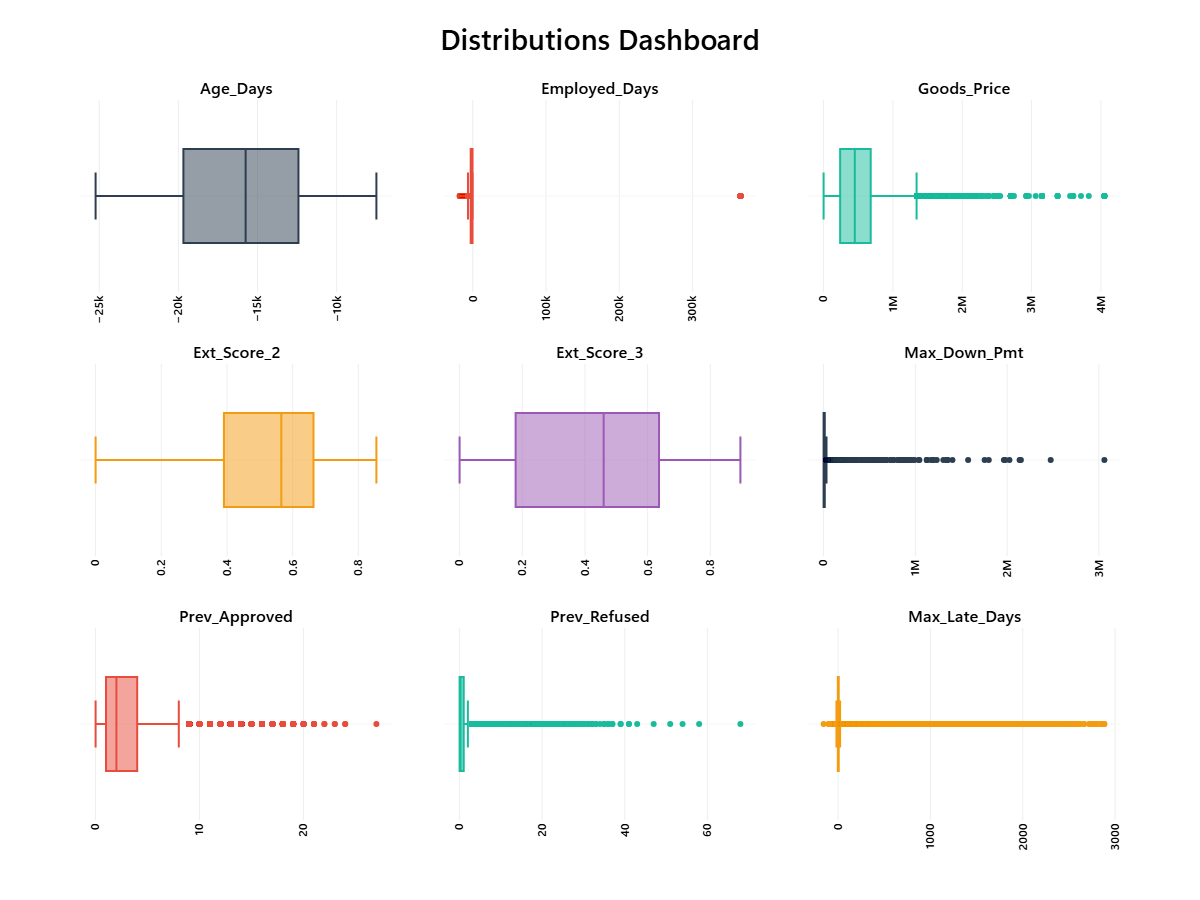

In [9]:
from plotly.subplots import make_subplots
cont_variables=['Age_Days', 'Employed_Days', 'Goods_Price', 
    'Ext_Score_2', 'Ext_Score_3', 'Max_Down_Pmt', 
    'Prev_Approved', 'Prev_Refused', 'Max_Late_Days']
fig_dash=make_subplots(
    rows=3,cols=3,subplot_titles=cont_variables,
    horizontal_spacing=0.05,
    vertical_spacing=0.1
)
for k,t in enumerate(cont_variables):
    rows=(k//3)+1
    columns=(k%3)+1
    fig_dash.add_trace(
        go.Box(x=df_eda[t],name=t),
        row=rows, col=columns
    )
fig_dash.update_layout(
    width=1200, height=900,
    showlegend=False,
    title_text="<b>Distributions Dashboard</b>"
    )
fig_dash.update_yaxes(showticklabels=False)
fig_dash.show()

From the distributions dashboard, we can see very curious box plot distributions for the variables Employed_Days, Goods_Price, Max_Down_Pmt, Prev_Approved, Prev_Refused, and Max_Late_Days. Also, these variables were the only ones graphed since the other variables were dummies or categorical. The reason why these variables have such weird distributions is because of the following reasons:




Employed_Days: The main reason is an outlier, specifically the number 365243, which as specified in the Home Credit columns description is the automatic number that the institution software gives to retired people, so it was modified to 0 for not losing the data.


Goods_Price and Max_Down_Pmt: These ones have asymmetric distributions primarily because they are money source variables, and usually these types of variables are very skewed in practice. To fix this, we transform them into logarithmic variables, applying $\ln{(X+1)}$ for avoiding the $X=0$ trap, as we are going to see further.


Prev_Approved and Prev_Refused: Actually, these ones are expected. It is very usual in financial institutions to have a majority of people with a stable amount of approved loans and very few ones with a lot of loans approved. It is very often to see a high concentration of people with similar rejections of credits.  
Max_Late_Days: This follows the same logic as Prev_Refused; these types of credit institutions have clients that are not used to being “responsible” with share payments or following payment schedules.


For fixing the distributions of Prev_Approved and Prev_Refused (even though they distribute as expected, we can’t have distributions like that for our model), we converted them into dummy variables. Since there is a lot of people with more than 1 accepted or refused credit, the decision was to split the accepted/rejected into 1 time and 2 or more.

In [10]:
df_eda=df_eda.assign(
    ln_Goods_Price=np.log1p(df_eda["Goods_Price"]),
    ln_Max_Down_Pmt=np.log1p(df_eda["Max_Down_Pmt"]),
    Refused_2_or_More=(df_eda["Prev_Refused"]>=2).astype(int),
    Refused_1_Time=(df_eda["Prev_Refused"]==1).astype(int),
    Approved_2_or_More=(df_eda["Prev_Approved"]>=2).astype(int),
    Approved_1_time=(df_eda["Prev_Approved"]==1).astype(int)
)
df_eda=df_eda.drop(columns=["Goods_Price","Max_Down_Pmt","Prev_Refused","Prev_Approved"])
df_eda

,Client_ID,Target,Is_Working,Ext_Score_2,Ext_Score_3,Edu_Higher,Has_Doc_3,Is_Male,Is_Pensioner,Is_New_Client,...,Max_Late_Days,Employed_Days,Rej_SCOFR,Is_Self_Employed,ln_Goods_Price,ln_Max_Down_Pmt,Refused_2_or_More,Refused_1_Time,Approved_2_or_More,Approved_1_time
0,100002,1,1,0.262949,0.139376,0,1,1,0,1.0,...,-12.0,-637,0.0,0,12.768544,0.000000,0,0,0,1
1,100003,0,0,0.622246,0.000000,1,1,0,0,0.0,...,-1.0,-1188,0.0,0,13.937287,8.837246,0,0,1,0
2,100004,0,1,0.555912,0.729567,0,0,1,0,1.0,...,-3.0,-225,0.0,0,11.813037,8.488999,0,0,0,1
3,100006,0,1,0.650442,0.000000,0,1,0,0,1.0,...,-1.0,-3039,0.0,0,12.601491,11.112269,0,1,1,0
4,100007,0,1,0.322738,0.000000,0,0,1,0,1.0,...,12.0,-3038,0.0,0,13.148033,8.209988,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,1,0.681632,0.000000,0,0,1,0,1.0,...,-8.0,-236,0.0,0,12.323860,0.000000,0,0,0,1
307507,456252,0,0,0.115992,0.000000,0,1,0,1,1.0,...,3.0,365243,0.0,0,12.323860,8.148156,0,0,0,1
307508,456253,0,1,0.535722,0.218859,1,1,0,0,0.0,...,9.0,-7921,0.0,0,13.279369,8.685078,0,0,1,0
307509,456254,1,0,0.514163,0.661024,0,1,0,0,1.0,...,-8.0,-4786,0.0,0,12.674516,0.000000,0,0,1,0


In [11]:
df_eda["Employed_Days"]=np.where(df_eda["Employed_Days"]==365243,0,df_eda["Employed_Days"])
df_eda

,Client_ID,Target,Is_Working,Ext_Score_2,Ext_Score_3,Edu_Higher,Has_Doc_3,Is_Male,Is_Pensioner,Is_New_Client,...,Max_Late_Days,Employed_Days,Rej_SCOFR,Is_Self_Employed,ln_Goods_Price,ln_Max_Down_Pmt,Refused_2_or_More,Refused_1_Time,Approved_2_or_More,Approved_1_time
0,100002,1,1,0.262949,0.139376,0,1,1,0,1.0,...,-12.0,-637,0.0,0,12.768544,0.000000,0,0,0,1
1,100003,0,0,0.622246,0.000000,1,1,0,0,0.0,...,-1.0,-1188,0.0,0,13.937287,8.837246,0,0,1,0
2,100004,0,1,0.555912,0.729567,0,0,1,0,1.0,...,-3.0,-225,0.0,0,11.813037,8.488999,0,0,0,1
3,100006,0,1,0.650442,0.000000,0,1,0,0,1.0,...,-1.0,-3039,0.0,0,12.601491,11.112269,0,1,1,0
4,100007,0,1,0.322738,0.000000,0,0,1,0,1.0,...,12.0,-3038,0.0,0,13.148033,8.209988,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,1,0.681632,0.000000,0,0,1,0,1.0,...,-8.0,-236,0.0,0,12.323860,0.000000,0,0,0,1
307507,456252,0,0,0.115992,0.000000,0,1,0,1,1.0,...,3.0,0,0.0,0,12.323860,8.148156,0,0,0,1
307508,456253,0,1,0.535722,0.218859,1,1,0,0,0.0,...,9.0,-7921,0.0,0,13.279369,8.685078,0,0,1,0
307509,456254,1,0,0.514163,0.661024,0,1,0,0,1.0,...,-8.0,-4786,0.0,0,12.674516,0.000000,0,0,1,0


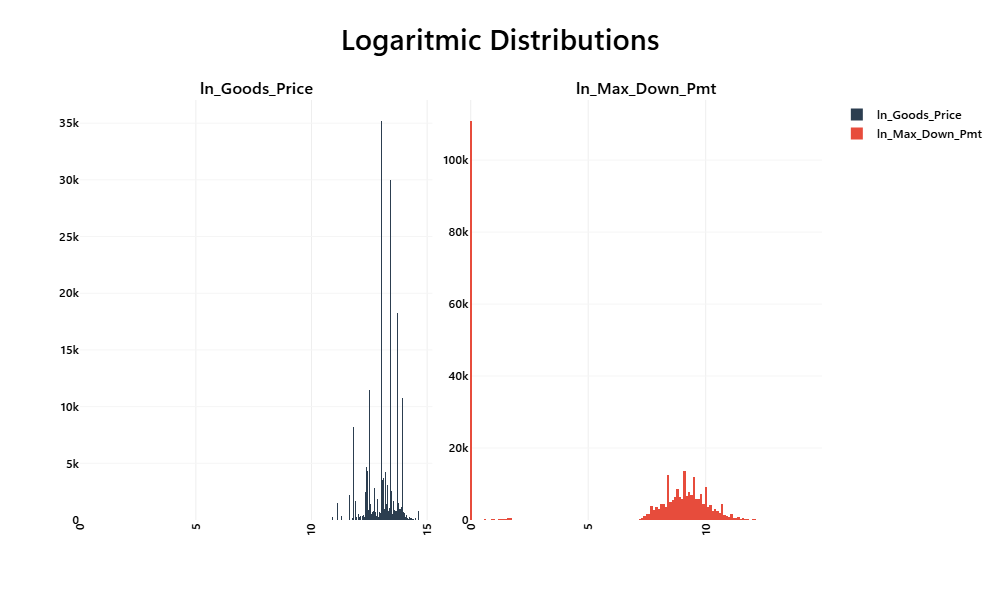

In [12]:
log_variables=["ln_Goods_Price","ln_Max_Down_Pmt"
]
fig_dash1=make_subplots(
    rows=1,cols=2,subplot_titles=log_variables,
    horizontal_spacing=0.05
)
for k,t in enumerate(log_variables):
    fig_dash1.add_trace(
        go.Histogram(x=df_eda[t],name=t),
        row=1,
        col=k+1
    )
fig_dash1.update_layout(title_text="<b>Logaritmic Distributions</b>")
fig_dash1.show(config={'scrollZoom': True})

Here we can see the distribution of the logarithmic Goods_Price and Max_Down_Pmt. From the right chart, we can see an unusual concentration in the 0 value, and following the same logic as stated before, it is very rare that clients of these institutions leave a first down payment. Since there's a high concentration of people who did not ever present a single down payment in their credit life, a dummy variable is defined. This was done with the intention of dropping Max_Down_Pmt in the future, since the extreme asymmetry could affect the estimated coefficients of our model. Since the Maximum Likelihood (ML) method attempts to minimize the quadratic score, an abnormally high concentration of 0 values would probably lower the coefficient. By defining a dummy variable, we save our estimated coefficient and keep capturing the effect of people who haven't ever paid a single down payment in their lives.

In [13]:
df_eda["Has_Down_Pmt"]=(df_eda["ln_Max_Down_Pmt"]>0).astype(int)
df_eda

,Client_ID,Target,Is_Working,Ext_Score_2,Ext_Score_3,Edu_Higher,Has_Doc_3,Is_Male,Is_Pensioner,Is_New_Client,...,Employed_Days,Rej_SCOFR,Is_Self_Employed,ln_Goods_Price,ln_Max_Down_Pmt,Refused_2_or_More,Refused_1_Time,Approved_2_or_More,Approved_1_time,Has_Down_Pmt
0,100002,1,1,0.262949,0.139376,0,1,1,0,1.0,...,-637,0.0,0,12.768544,0.000000,0,0,0,1,0
1,100003,0,0,0.622246,0.000000,1,1,0,0,0.0,...,-1188,0.0,0,13.937287,8.837246,0,0,1,0,1
2,100004,0,1,0.555912,0.729567,0,0,1,0,1.0,...,-225,0.0,0,11.813037,8.488999,0,0,0,1,1
3,100006,0,1,0.650442,0.000000,0,1,0,0,1.0,...,-3039,0.0,0,12.601491,11.112269,0,1,1,0,1
4,100007,0,1,0.322738,0.000000,0,0,1,0,1.0,...,-3038,0.0,0,13.148033,8.209988,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,1,0.681632,0.000000,0,0,1,0,1.0,...,-236,0.0,0,12.323860,0.000000,0,0,0,1,0
307507,456252,0,0,0.115992,0.000000,0,1,0,1,1.0,...,0,0.0,0,12.323860,8.148156,0,0,0,1,1
307508,456253,0,1,0.535722,0.218859,1,1,0,0,0.0,...,-7921,0.0,0,13.279369,8.685078,0,0,1,0,1
307509,456254,1,0,0.514163,0.661024,0,1,0,0,1.0,...,-4786,0.0,0,12.674516,0.000000,0,0,1,0,0


Now comes the tricky part: we have a dataset of 23 possible variables for our model. This could scream collinearity to us, but we need proof of actual collinearity in the model.  For that, we start measuring the correlations for all variables. To illustrate this, we can see this (not so much) cute heatmap graph of correlations. I admit that I included the graph since I thought it looked cuter than it actually does, but since it is not really that intuitive, I printed a list of the correlation pairs as well.

In [14]:
correlations=df_eda.drop(columns=["Client_ID","Target"]).corr()

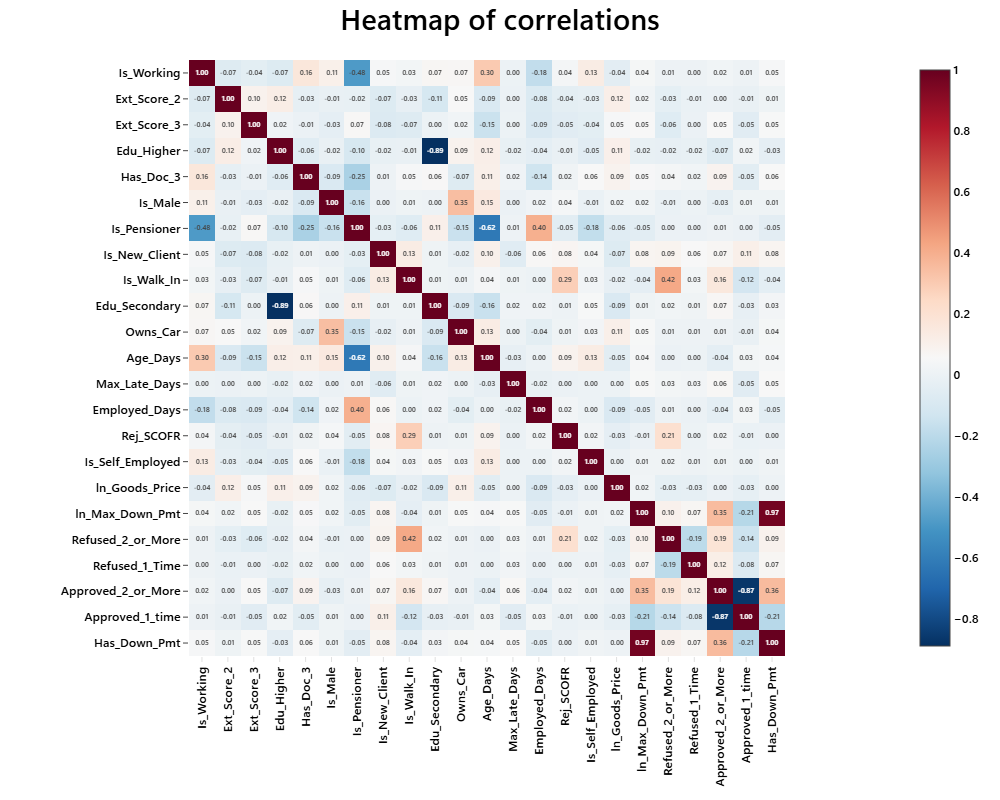

In [15]:
fig1=px.imshow(
    correlations,
    text_auto=".2f",
    aspect="equal",
    color_continuous_scale="RdBu_r"
)
fig1.update_layout(title_text="<b>Heatmap of correlations</b>",width=1000,height=800)
fig1.show(config={'scrollZoom': True})

In [17]:
plain_list=correlations.unstack().abs().sort_values(ascending=False)
top_correlations=plain_list[plain_list<0.99]
top_correlations=top_correlations[::2]
top_correlations.head(20)

Has_Down_Pmt        ln_Max_Down_Pmt       0.969458
Edu_Secondary       Edu_Higher            0.888002
Approved_1_time     Approved_2_or_More    0.867767
Age_Days            Is_Pensioner          0.620069
Is_Working          Is_Pensioner          0.484125
Is_Walk_In          Refused_2_or_More     0.419677
Employed_Days       Is_Pensioner          0.396855
Approved_2_or_More  Has_Down_Pmt          0.358312
ln_Max_Down_Pmt     Approved_2_or_More    0.354793
Owns_Car            Is_Male               0.345841
Is_Working          Age_Days              0.304568
Is_Walk_In          Rej_SCOFR             0.285288
Is_Pensioner        Has_Doc_3             0.248351
Approved_1_time     ln_Max_Down_Pmt       0.212239
Has_Down_Pmt        Approved_1_time       0.210835
Rej_SCOFR           Refused_2_or_More     0.208529
Refused_1_Time      Refused_2_or_More     0.194361
Approved_2_or_More  Refused_2_or_More     0.187329
Employed_Days       Is_Working            0.178362
Is_Pensioner        Is_Self_Emp

From the list, we can see very high correlations. Naturally, Has_Down_Pmt and ln_Max_Down_Pmt have the highest correlation of the dataset since the first one was calculated from the second one, so one of this pair is the first candidate to go. Then we have Edu_Secondary and Edu_Higher; I don’t even have to say why they are correlated (but I will), it is because people who have a higher education already have a secondary education. The third, of course, is Approved_2_or_More and Approved_1_Time. Here I started to question myself if it was a dumb decision to split them into 1 time and 2 or more, and just simply include them both in Approved_1_or_More, but anyways. The fourth high correlation is Age_Days and Is_Pensioner. The second one is a dummy originated from the original variable NAME_INCOME_TYPE=Pensioner, and of course it is very correlated with Age_Days since this variable is measured as days of birth taking the day that the person asked for the loan as reference; therefore, a higher age will naturally be correlated with receiving a pension.

A very sane statistical mind would drop almost half of the variables from the correlation table, but I decided to let the data speak for itself, so I ran a VIF test. What the VIF basically does is to regress the variable as dependent against the rest of the other variables as independents. It is basically a traditional linear regression with the goal of finding the highest $R^2$, since this statistic of goodness of fit tells us how much of the variability is explained by the rest of the variables. We define the VIF as:$$VIF_j = \frac{1}{1 - R_j^2}$$The greater the $R^2$, the greater the VIF. This means that it is almost certain that the variable with the highest $R^2$ is giving collinearity to the model. And why is this important? Is it just statistical fanciness? A lot of academics would feel very important defining this, but I will just say yes: if our model has collinearity, our important coefficients would likely be statistically insignificant, since they will be capturing the effect of 2 variables at the same time. What’s going on with that? Well, our inferences will be completely flawed. We are looking for a VIF not higher than 5.

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif_clean=df_eda.drop(columns=["Client_ID","Target"])
X_vif_const=sm.add_constant(X_vif_clean)
vif_data=pd.DataFrame()
vif_data["Variable"]=X_vif_const.columns
vif_data["VIF"]=[variance_inflation_factor(X_vif_const.values,i) for i in range(len(X_vif_const.columns))]
vif_data = vif_data[vif_data["Variable"] != "const"]
vif_data=vif_data.sort_values(by="VIF",ascending=False).reset_index(drop=True)
vif_data

,Variable,VIF
0,Has_Down_Pmt,16.956523
1,ln_Max_Down_Pmt,16.891783
2,Approved_2_or_More,5.433473
3,Approved_1_time,4.883755
4,Edu_Secondary,4.823077
5,Edu_Higher,4.813460
6,Is_Pensioner,2.708144
7,Age_Days,1.961660
8,Employed_Days,1.376302
9,Is_Working,1.358737


From the table we can see that, as we suspected before, we have to let go of ln_Max_Down_Pmt. And I know what I said, but Approved_2_or_More has only 0.43 of additional VIF than what I defined earlier, so it is not really a big deal, we keep it.

In [21]:
df_eda=df_eda.drop(columns=["ln_Max_Down_Pmt"])
df_eda

,Client_ID,Target,Is_Working,Ext_Score_2,Ext_Score_3,Edu_Higher,Has_Doc_3,Is_Male,Is_Pensioner,Is_New_Client,...,Max_Late_Days,Employed_Days,Rej_SCOFR,Is_Self_Employed,ln_Goods_Price,Refused_2_or_More,Refused_1_Time,Approved_2_or_More,Approved_1_time,Has_Down_Pmt
0,100002,1,1,0.262949,0.139376,0,1,1,0,1.0,...,-12.0,-637,0.0,0,12.768544,0,0,0,1,0
1,100003,0,0,0.622246,0.000000,1,1,0,0,0.0,...,-1.0,-1188,0.0,0,13.937287,0,0,1,0,1
2,100004,0,1,0.555912,0.729567,0,0,1,0,1.0,...,-3.0,-225,0.0,0,11.813037,0,0,0,1,1
3,100006,0,1,0.650442,0.000000,0,1,0,0,1.0,...,-1.0,-3039,0.0,0,12.601491,0,1,1,0,1
4,100007,0,1,0.322738,0.000000,0,0,1,0,1.0,...,12.0,-3038,0.0,0,13.148033,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,1,0.681632,0.000000,0,0,1,0,1.0,...,-8.0,-236,0.0,0,12.323860,0,0,0,1,0
307507,456252,0,0,0.115992,0.000000,0,1,0,1,1.0,...,3.0,0,0.0,0,12.323860,0,0,0,1,1
307508,456253,0,1,0.535722,0.218859,1,1,0,0,0.0,...,9.0,-7921,0.0,0,13.279369,0,0,1,0,1
307509,456254,1,0,0.514163,0.661024,0,1,0,0,1.0,...,-8.0,-4786,0.0,0,12.674516,0,0,1,0,0


## **Modeling**


This is where the fun begins (for any Star Wars reference). In this sub-section, the dataframe is prepared for the model, the model is defined, and we transform variables using the WoE ponderation or “binning” for adjusting the categorical variables. Unfortunately, I realized I had to do this after defining the first model, so I had to go back to the previous dataframe to transform the variables and re-estimate the model.

In this section, I also show the process of Stacking OOF, which was discovered while investigating how to increase the ROC-AUC metric of the original model.  For reference, I'm a senior economics student. In our career, we do not see Machine Learning too deeply, we focus mostly on econometric models and try not to break any statistical rules, as the data allows us to model reality. My first intention was to literally create a variable using XGBoost to insert into my logistic model. The plan was to estimate a variable using the residuals of my original logistic model with XGBoost and then re-estimate the logit model. Then I realized this would be a massive mistake, and this is where the theoretical background of my career really paid off. One of the conditions (or assumptions) to estimate is the normality of errors. Estimating a variable through XGBoost using the residuals of the original logistic model would violate just that; the error would not be normal but would already be estimated by the model. That leads to spurious regressions, so all of our inferences or explanations of causality would be flawed.

So the definitive approach that I took is the Stacking OOF (Out-Of-Fold), which basically consists in splitting the dataset for training in $K$ parts, estimating the split dataset with the $K-1$ split dataset using XGBoost so there is no overfitting, and then stacking all the datasets again. We will have a brand new variable of probabilities that might not contribute in an explanatory way, but it helps us to raise the ROC-AUC and predictive capability of the model.

In [ ]:
df_eda.to_csv("home_credit_model.csv")

In [ ]:
df_eda=pd.read_csv("home_credit_model.csv")
df_eda=df_eda.drop(columns="Unnamed: 0")
df_eda

,Client_ID,Target,Is_Working,Ext_Score_2,Ext_Score_3,Edu_Higher,Has_Doc_3,Is_Male,Is_Pensioner,Is_New_Client,...,Max_Late_Days,Employed_Days,Rej_SCOFR,Is_Self_Employed,ln_Goods_Price,Refused_2_or_More,Refused_1_Time,Approved_2_or_More,Approved_1_time,Has_Down_Pmt
0,100002,1,1,0.262949,0.139376,0,1,1,0,1.0,...,-12.0,-637,0.0,0,12.768544,0,0,0,1,0
1,100003,0,0,0.622246,0.000000,1,1,0,0,0.0,...,-1.0,-1188,0.0,0,13.937287,0,0,1,0,1
2,100004,0,1,0.555912,0.729567,0,0,1,0,1.0,...,-3.0,-225,0.0,0,11.813037,0,0,0,1,1
3,100006,0,1,0.650442,0.000000,0,1,0,0,1.0,...,-1.0,-3039,0.0,0,12.601491,0,1,1,0,1
4,100007,0,1,0.322738,0.000000,0,0,1,0,1.0,...,12.0,-3038,0.0,0,13.148033,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,1,0.681632,0.000000,0,0,1,0,1.0,...,-8.0,-236,0.0,0,12.323860,0,0,0,1,0
307507,456252,0,0,0.115992,0.000000,0,1,0,1,1.0,...,3.0,0,0.0,0,12.323860,0,0,0,1,1
307508,456253,0,1,0.535722,0.218859,1,1,0,0,0.0,...,9.0,-7921,0.0,0,13.279369,0,0,1,0,1
307509,456254,1,0,0.514163,0.661024,0,1,0,0,1.0,...,-8.0,-4786,0.0,0,12.674516,0,0,1,0,0


We start with the train_test_split function of scikit-learn for splitting the dataset into the training matrix and the test matrix.

In [5]:
from sklearn.model_selection import train_test_split
X_model=df_eda.drop(columns=["Client_ID","Target"])
y_model=df_eda["Target"]
X_model_train,X_model_test,y_model_train,y_model_test=train_test_split(
    X_model,y_model,
    test_size=0.20, random_state=73
)
print(f"Train Sample Dimentions: {X_model_train.shape}\nTest Sample Dimentions: {X_model_test.shape}")

Train Sample Dimentions: (246008, 22)
Test Sample Dimentions: (61503, 22)


In [6]:
X_train_const=sm.add_constant(X_model_train)
logit_model=sm.Logit(y_model_train,X_train_const)
logit_results=logit_model.fit()
print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.255938
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:               246008
Model:                          Logit   Df Residuals:                   245985
Method:                           MLE   Df Model:                           22
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                 0.08858
Time:                        17:20:49   Log-Likelihood:                -62963.
converged:                       True   LL-Null:                       -69082.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.9137      0.144    -13.250      0.000      -2.197      -1.631
Is_Wo

In the first logistic iteration, as we can see, all variables are statistically significant except for Approved_2_or_More. Here I realized what I suspected before was right: I should have just used one dummy variable. Other than that, the estimations look really well.

In [7]:
from sklearn.metrics import accuracy_score, roc_auc_score
X_test_const=sm.add_constant(X_model_test)
y_pred_proba=logit_results.predict(X_test_const)
y_pred_class=(y_pred_proba>=0.5).astype(int)
auc=roc_auc_score(y_model_test,y_pred_proba)
acc=accuracy_score(y_model_test,y_pred_class)
print(f"ROC-AUC: {auc:.4f}\nAccuracy: {acc:.4f}")

ROC-AUC: 0.7233
Accuracy: 0.9197


As we can see, the ROC-AUC of the first model is not too high, but not low.  If I adjust the variables with WoE, the model might get a bit better at predicting the data.

Here I unified both dummy variables of Approved_1_time and Approved_2_or_More into Has_Pre_Approved, due to the statistical insignificance of the latter, as I should have done from the beginning.

In [8]:
df_eda["Has_Pre_Approved"]=df_eda["Approved_1_time"]+df_eda["Approved_2_or_More"]
df_eda=df_eda.drop(columns=["Approved_1_time","Approved_2_or_More"])
df_eda

,Client_ID,Target,Is_Working,Ext_Score_2,Ext_Score_3,Edu_Higher,Has_Doc_3,Is_Male,Is_Pensioner,Is_New_Client,...,Age_Days,Max_Late_Days,Employed_Days,Rej_SCOFR,Is_Self_Employed,ln_Goods_Price,Refused_2_or_More,Refused_1_Time,Has_Down_Pmt,Has_Pre_Approved
0,100002,1,1,0.262949,0.139376,0,1,1,0,1.0,...,-9461,-12.0,-637,0.0,0,12.768544,0,0,0,1
1,100003,0,0,0.622246,0.000000,1,1,0,0,0.0,...,-16765,-1.0,-1188,0.0,0,13.937287,0,0,1,1
2,100004,0,1,0.555912,0.729567,0,0,1,0,1.0,...,-19046,-3.0,-225,0.0,0,11.813037,0,0,1,1
3,100006,0,1,0.650442,0.000000,0,1,0,0,1.0,...,-19005,-1.0,-3039,0.0,0,12.601491,0,1,1,1
4,100007,0,1,0.322738,0.000000,0,0,1,0,1.0,...,-19932,12.0,-3038,0.0,0,13.148033,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,1,0.681632,0.000000,0,0,1,0,1.0,...,-9327,-8.0,-236,0.0,0,12.323860,0,0,0,1
307507,456252,0,0,0.115992,0.000000,0,1,0,1,1.0,...,-20775,3.0,0,0.0,0,12.323860,0,0,1,1
307508,456253,0,1,0.535722,0.218859,1,1,0,0,0.0,...,-14966,9.0,-7921,0.0,0,13.279369,0,0,1,1
307509,456254,1,0,0.514163,0.661024,0,1,0,0,1.0,...,-11961,-8.0,-4786,0.0,0,12.674516,0,0,0,1


In [9]:
X_model=df_eda.drop(columns=["Client_ID","Target"])
y_model=df_eda["Target"]
X_model_train,X_model_test,y_model_train,y_model_test=train_test_split(
    X_model,y_model,
    test_size=0.20, random_state=73
)
print(f"Train Sample Dimentions: {X_model_train.shape}\nTest Sample Dimentions: {X_model_test.shape}")

Train Sample Dimentions: (246008, 21)
Test Sample Dimentions: (61503, 21)


In [10]:
X_train_const=sm.add_constant(X_model_train)
logit_model_v2=sm.Logit(y_model_train,X_train_const)
logit_v2_results=logit_model_v2.fit()
print(logit_v2_results.summary())

Optimization terminated successfully.
         Current function value: 0.256161
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:               246008
Model:                          Logit   Df Residuals:                   245986
Method:                           MLE   Df Model:                           21
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                 0.08779
Time:                        17:43:15   Log-Likelihood:                -63018.
converged:                       True   LL-Null:                       -69082.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.8572      0.144    -12.898      0.000      -2.139      -1.575
Is_Worki

In [12]:
X_test_const=sm.add_constant(X_model_test)
y_pred_proba=logit_v2_results.predict(X_test_const)
y_pred_class=(y_pred_proba>=0.5).astype(int)
auc=roc_auc_score(y_model_test,y_pred_proba)
acc=accuracy_score(y_model_test,y_pred_class)
print(f"ROC-AUC: {auc:.4f}\nAccuracy: {acc:.4f}")

ROC-AUC: 0.7222
Accuracy: 0.9198


Once again, the model yielded a slightly lower ROC-AUC, but in this case it makes sense since we eliminated a variable.

Here I realized what I should have done since the beginning of this section: transform the categorical variables with WoE. So I went back to the previous EDA dataframe. During this process, and thankfully to the DataWrangler extension of VSCode, I checked the data and realized that three of the variables were not brought as dummies from the SQL cleaning process. This was a great mistake that I thankfully realized and decided to fix. In this big single code block, I addressed the dummies correctly, converted the Days variables into Years for better understanding of the coefficients and for a better fit of the WoE, did the train-test split once again, and ran a VIF for this new dataset just to be cautious.

(During this process, I considered using the classical econometric approach of including quadratic age and experience into the model, since it has an inverted U effect on the dependent variable—younger and older people are equally likely to default, while middle-aged people are more likely to pay. But since the WoE approach is the rule in the credit risk industry, I decided to go with WoE)

In [2]:
df_eda_og=pd.read_csv("home_credit_relevant_variables_renamed.csv")
df_eda_og=df_eda_og.drop(columns=["Unnamed: 0"])

In [3]:
list(df_eda_og.columns)

['Client_ID',
 'Target',
 'Is_Working',
 'Ext_Score_2',
 'Ext_Score_3',
 'Edu_Higher',
 'Has_Doc_3',
 'Is_Male',
 'Is_Pensioner',
 'Is_New_Client',
 'Is_Walk_In',
 'Max_Down_Pmt',
 'Edu_Secondary',
 'Owns_Car',
 'Prev_Approved',
 'Goods_Price',
 'Prev_Refused',
 'Age_Days',
 'Max_Late_Days',
 'Employed_Days',
 'Rej_SCOFR',
 'Is_Self_Employed']

In [4]:
df_eda_og[["Is_New_Client","Is_Walk_In","Rej_SCOFR"]].describe()

,Is_New_Client,Is_Walk_In,Rej_SCOFR
count,307511.000000,307511.000000,307511.000000
mean,0.844002,0.417071,0.035365
std,0.586482,1.071978,0.300046
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000
max,26.000000,42.000000,28.000000


In [5]:
import category_encoders as ce
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
#Fixing columns problems
columns_to_fix=["Is_New_Client","Is_Walk_In","Rej_SCOFR"]
for col in columns_to_fix:
    df_eda_og[col]=(df_eda_og[col]>0).astype(int)
df_eda_og['ln_Goods_Price']=np.log1p(df_eda_og['Goods_Price'])
df_eda_og = df_eda_og.drop(columns=['Goods_Price'])
#Transforming to Years the Days variables
df_eda_og["Age_Years"]=df_eda_og["Age_Days"]/365.25
df_eda_og["Employed_Years"]=np.where(df_eda_og["Employed_Days"]==365243,0,df_eda_og["Employed_Days"]/365.25)
#Binning Variables
df_eda_og["Age_Binned"]=pd.qcut(df_eda_og["Age_Years"],q=10,duplicates="drop").astype(str)
df_eda_og["Employed_Binned"]=pd.qcut(df_eda_og["Employed_Years"],q=10,duplicates="drop").astype(str)
#Re-defining the model matrix
X_model=df_eda_og.drop(columns=[
    "Client_ID","Target",
    "Age_Days","Employed_Days","Age_Years","Employed_Years"
])
y_model=df_eda_og["Target"]
X_model_train, X_model_test, y_model_train, y_model_test=train_test_split(
    X_model,y_model,test_size=0.2,random_state=73
)
#WoE Transformation
woe_columns=["Prev_Approved","Prev_Refused","Age_Binned","Employed_Binned"]
woe_encoder=ce.WOEEncoder(cols=woe_columns)
X_model_train_woe=woe_encoder.fit_transform(X_model_train,y_model_train)
X_model_test_woe=woe_encoder.transform(X_model_test)
#VIF Again
X_model_train_woe_const=sm.add_constant(X_model_train_woe)
vif_data=pd.DataFrame()
vif_data["Variable"]=X_model_train_woe_const.columns
vif_data["VIF"]=[variance_inflation_factor(X_model_train_woe_const.values,i) for i in range(len(X_model_train_woe_const.columns))]
vif_data=vif_data[vif_data["Variable"]!="const"].sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data.head(10))

          Variable       VIF
0    Edu_Secondary  4.819849
1       Edu_Higher  4.809750
2     Is_Pensioner  2.223332
3       Age_Binned  1.924953
4  Employed_Binned  1.372832
5       Is_Working  1.359289
6     Prev_Refused  1.273488
7       Is_Walk_In  1.221167
8         Owns_Car  1.187026
9    Prev_Approved  1.185741


The VIF shows us no collinearity risks, so we can proceed to re-estimate the logistic model.

For some reason, I decided to name this logit_goat, believing the ROC-AUC would be considerably higher.

In [10]:
logit_goat=sm.Logit(y_model_train,X_model_train_woe_const)
goat_results=logit_goat.fit()
print(goat_results.summary())

Optimization terminated successfully.
         Current function value: 0.255580
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:               246008
Model:                          Logit   Df Residuals:                   245987
Method:                           MLE   Df Model:                           20
Date:                vie, 10 abr 2026   Pseudo R-squ.:                 0.08986
Time:                        20:13:36   Log-Likelihood:                -62875.
converged:                       True   LL-Null:                       -69082.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.5344      0.050    -30.985      0.000      -1.631      -1.437
Is_Working 

Here we can see all the variables are statistically significant, except for Goods_Price. Since in this model the variable was not transformed to logarithmic, now we transform the variable and re-estimate the model.

In [ ]:
df_eda_og['ln_Goods_Price']=np.log1p(df_eda_og['Goods_Price'])
df_eda_og = df_eda_og.drop(columns=['Goods_Price'])
X_model=df_eda_og.drop(columns=[
    "Client_ID","Target",
    "Age_Days","Employed_Days","Age_Years","Employed_Years"
])
y_model=df_eda_og["Target"]
X_model_train, X_model_test, y_model_train, y_model_test=train_test_split(
    X_model,y_model,test_size=0.2,random_state=73
)
woe_columns=["Prev_Approved","Prev_Refused","Age_Binned","Employed_Binned"]
woe_encoder=ce.WOEEncoder(cols=woe_columns)
X_model_train_woe=woe_encoder.fit_transform(X_model_train,y_model_train)
X_model_test_woe=woe_encoder.transform(X_model_test)
#VIF Again
X_model_train_woe_const=sm.add_constant(X_model_train_woe)
vif_data=pd.DataFrame()
vif_data["Variable"]=X_model_train_woe_const.columns
vif_data["VIF"]=[variance_inflation_factor(X_model_train_woe_const.values,i) for i in range(len(X_model_train_woe_const.columns))]
vif_data=vif_data[vif_data["Variable"]!="const"].sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data.head(10))

          Variable       VIF
0    Edu_Secondary  4.819849
1       Edu_Higher  4.809750
2     Is_Pensioner  2.223332
3       Age_Binned  1.924953
4  Employed_Binned  1.372832
5       Is_Working  1.359289
6     Prev_Refused  1.273488
7       Is_Walk_In  1.221167
8         Owns_Car  1.187026
9    Prev_Approved  1.185741


After re-defining the train and test matrix, re-transforming the variables with WoE, checking the VIF (again, no collinearity risks), it was time to re-estimate the “goat” logistic model. 

In [12]:
logit_goat_v2=sm.Logit(y_model_train,X_model_train_woe_const)
goat_results=logit_goat_v2.fit()
print(goat_results.summary())

Optimization terminated successfully.
         Current function value: 0.255467
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:               246008
Model:                          Logit   Df Residuals:                   245987
Method:                           MLE   Df Model:                           20
Date:                vie, 10 abr 2026   Pseudo R-squ.:                 0.09026
Time:                        20:18:15   Log-Likelihood:                -62847.
converged:                       True   LL-Null:                       -69082.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.5221      0.144    -17.470      0.000      -2.805      -2.239
Is_Working 

All variables were statistically significant.

In [13]:
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
X_model_test_woe_const=sm.add_constant(X_model_test_woe)
y_pred_proba_goat = goat_results.predict(X_model_test_woe_const)
auc_goat = roc_auc_score(y_model_test, y_pred_proba_goat)
y_pred_class_goat = (y_pred_proba_goat >= 0.5).astype(int)
acc_goat = accuracy_score(y_model_test, y_pred_class_goat)
print(f"ROC-AUC: {auc_goat:.4f}\nAccuracy: {acc_goat:.4f}")

ROC-AUC: 0.7240
Accuracy: 0.9199


Not so goated (for now)

Now the idea of the Stacking OOF method comes into play.

We import the StratifiedKFold function. Now we have the new variable, completely predicted with the XGBoost model, and it is time to re-estimate the final boss model (VIF first, naturally).

In [15]:
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
oof_preds_xgb=np.zeros(len(X_model_train_woe_const))
test_preds_xgb=np.zeros(len(X_model_test_woe_const))
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=73)
X_train_np=X_model_train_woe_const.values
y_train_np=y_model_train.values
X_test_np=X_model_test_woe_const.values
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_np, y_train_np)):
    X_fold_train, y_fold_train = X_train_np[train_idx], y_train_np[train_idx]
    X_fold_val, y_fold_val = X_train_np[val_idx], y_train_np[val_idx]    
    model_xgb = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=73,
        n_jobs=-1
    )
    model_xgb.fit(X_fold_train, y_fold_train)
    oof_preds_xgb[val_idx] = model_xgb.predict_proba(X_fold_val)[:, 1]
    
    
    test_preds_xgb += model_xgb.predict_proba(X_test_np)[:, 1] / skf.n_splits

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_meta_train = pd.DataFrame(X_model_train_woe_const)
X_meta_test = pd.DataFrame(X_model_test_woe_const)
X_meta_train['XGB_Pred_Proba'] = oof_preds_xgb
X_meta_test['XGB_Pred_Proba'] = test_preds_xgb
vif_data=pd.DataFrame()
vif_data["Variable"]=X_meta_train.columns
vif_data["VIF"]=[variance_inflation_factor(X_meta_train.values,i) for i in range(len(X_meta_train.columns))]
vif_data=vif_data[vif_data["Variable"]!="const"].sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data.head(10))

          Variable       VIF
0    Edu_Secondary  4.832630
1       Edu_Higher  4.817317
2   XGB_Pred_Proba  2.671690
3     Is_Pensioner  2.226579
4       Age_Binned  1.953713
5      Ext_Score_2  1.630509
6  Employed_Binned  1.420234
7       Is_Working  1.368006
8     Prev_Refused  1.345568
9      Ext_Score_3  1.293614


In [17]:
logit_meta_goat=sm.Logit(y_model_train,X_meta_train)
meta_results=logit_meta_goat.fit()
print(meta_results.summary())

Optimization terminated successfully.
         Current function value: 0.250778
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:               246008
Model:                          Logit   Df Residuals:                   245986
Method:                           MLE   Df Model:                           21
Date:                vie, 10 abr 2026   Pseudo R-squ.:                  0.1070
Time:                        21:27:58   Log-Likelihood:                -61693.
converged:                       True   LL-Null:                       -69082.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.1193      0.147    -21.201      0.000      -3.408      -2.831
Is_Working 

With this new dataset, the Max_Late_Days and Edu_Secondary variables are now statistically insignificant. That might be because of the addition of the XGB_Pred_Proba which absorbs their variance and helps in the probability fitting of the model. We drop the variables and re-estimate.

In [18]:
columns_to_drop=["Max_Late_Days", "Edu_Secondary"]
X_meta_train_clean=X_meta_train.drop(columns=columns_to_drop)
X_meta_test_clean=X_meta_test.drop(columns=columns_to_drop)
logit_meta_goat_v2=sm.Logit(y_model_train,X_meta_train_clean)
results_meta_goat=logit_meta_goat_v2.fit()
print(results_meta_goat.summary())

Optimization terminated successfully.
         Current function value: 0.250787
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:               246008
Model:                          Logit   Df Residuals:                   245988
Method:                           MLE   Df Model:                           19
Date:                vie, 10 abr 2026   Pseudo R-squ.:                  0.1069
Time:                        21:32:13   Log-Likelihood:                -61696.
converged:                       True   LL-Null:                       -69082.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.0614      0.144    -21.330      0.000      -3.343      -2.780
Is_Working 

Now is time for the moment of truth, the last ROC-AUC.

In [20]:
y_pred_proba_meta=results_meta_goat.predict(X_meta_test_clean)
auc_meta=roc_auc_score(y_model_test, y_pred_proba_meta)
y_pred_class_meta=(y_pred_proba_meta >= 0.5).astype(int)
acc_meta=accuracy_score(y_model_test, y_pred_class_meta)
print(f"ROC-AUC: {auc_meta:.4f}\nAccuracy: {acc_meta:.4f}")

ROC-AUC: 0.7456
Accuracy: 0.9195


Not a massive improvement, and certainly way lower than I originally dreamed of, but this is just the reality of the data. There are a lot more techniques to artificially increase this score, but the truth is that it is actually a pretty solid score for retail credit risk. The trade-off between gaining a tiny bit more of the score and spending hours investigating other mathematical ways to do, therefore seemed not worth it. To wrap things up, I decided to do a confusion matrix to illustrate better the actual capabilities of the model.

In [24]:
cm_final=confusion_matrix(y_model_test,y_pred_class_meta)
fig_cm=px.imshow(
    cm_final,
    text_auto=True,
    labels=dict(x="Meta-Model Prediction",y="Real Target"),
    x=["Paid(0)", "Default(1)"],
    y=["Paid(0)", "Default(1)"]
)
fig_cm.update_layout(
    title_text="<b>Confusion Matrix</b>"
)

## **Insights**

Now comes the explanatory part, and maybe where I could justify my payment: the insights of the model. Particularly, the Average Marginal Effects (AME) of each variable.

This is where the logistic model is very powerful by itself. Combining it with Machine Learning predictions not only gives us a model that is very good at predicting data, but also at explaining why it may happen.
The AME is defined as:
$$AME_k = \frac{1}{N} \sum_{i=1}^N \frac{\partial P(Y_i=1 \mid X_i)}{\partial X_{ik}}$$

In [26]:
ame=results_meta_goat.get_margeff(at='overall')
print(ame.summary())

        Logit Marginal Effects       
Dep. Variable:                 Target
Method:                          dydx
At:                           overall
                      dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Is_Working           0.0054      0.001      4.404      0.000       0.003       0.008
Ext_Score_2         -0.0562      0.003    -17.243      0.000      -0.063      -0.050
Ext_Score_3         -0.0404      0.002    -17.677      0.000      -0.045      -0.036
Edu_Higher          -0.0131      0.001     -9.081      0.000      -0.016      -0.010
Has_Doc_3            0.0077      0.001      5.842      0.000       0.005       0.010
Is_Male              0.0114      0.001      9.613      0.000       0.009       0.014
Is_Pensioner         0.0067      0.002      2.956      0.003       0.002       0.011
Is_New_Client        0.0045      0.001      3.011      0.003       0.002       0.00

External Scores: Ext_Score_2 and 3. The external credit ratings are the most significant protective factors against credit risk. A one-unit increase in Ext_Score_2 decreases on average the likelihood of default by 5.62%. This means that the provided data from external sources is key to predicting if a client is going to default or not; the first obvious rule is to reject clients with a bad External Score.


Demographic factors: Edu_Higher, Owns_Car and Is_Male. This is pretty straightforward. People with better education are more likely to pay their loans. A highly educated person is often interested in moving up in the economic class, and for that, needs financing for better goods, houses, etc. Therefore, a highly educated person is 1.31% less likely to default than those who don’t have a higher education. Cars, on the other hand, act as liquid assets. If a person has financial problems, selling their car could act as a lifesaver; these people are 0.71% less likely to default on their loans. Finally, regarding gender, the data says that if the client is a man, he is actually 1.14% more likely to default his loan on average than if the client is a woman (based on the positive coefficient where Y=1 represents default).


Credit History: Prev_Refused and Prev_Approved follow the expected tendencies. If a person has been rejected multiple times in the past, it is very likely that they will default when accepted. Specifically, these people have a 2.06% higher likelihood of defaulting a loan on average. On the other hand, people that have an excessive volume of approved credits before follow a similar risk trend. This is associated with an irresponsible financial behavior of over-leveraging; these people have a likelihood of 1.
66% of defaulting their loans on average.


Credit Structuring and Leverage: ln_Goods_Price. The model confirms an inelastic but positive relationship between the financed asset's price and credit risk. For every logarithmic unit increase in the price of the goods, the default probability rises by 0.22%. This captures the natural leverage effect: higher loan amounts for more expensive goods marginally increase the borrower's financial strain.

## **Conclusion**

The main conclusion that we can extract from this project is that, in this particular dataset for the year 2018, even though the defaulting rate is only 8%, the default phenomenon is closely related to behavioral and human capital factors rather than just macroeconomic ones. The characteristics that make a person “financially responsible” are the ones that actually explain and predict if this person is going to default or not, as we stated in the insights section.  
The deterioration is primarily behavioral. We have seen that the main reasons are linked to external scoring ratings and behavior linked to human capital status (people better educated exhibit more responsible financial behavior). The main advice from this analysis is to rely heavily on external scoring, limit big credits for people who do not have a solid educational/financial background or belong to statistically riskier demographic sectors, and closely monitor clients that have a history of problematic credit rejections or excessive loan requests.